# Feature Validation Plots (Interactive)

This notebook validates extracted features against raw IMU signals for one chosen folder.

You can:
- choose a directory using **tkinter**, or
- use `DATA_ROOT / PATIENT_ID / DATE`.

It supports layouts where activity CSVs are direct or nested. If multiple files match,
it prefers filenames containing `synchronized`.

## Imports

In [1]:
from pathlib import Path
import re
import warnings
import tkinter as tk
from tkinter import filedialog
import ipywidgets as widgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imu_features.config import PipelineConfig
from imu_features.utils import (
    preprocess_activity_dataframe,
    standardize_sensor_columns,
    timestamp_to_seconds,
    detect_peaks,
    dominant_frequency,
    safe_gradient,
    count_pauses,
    select_motion_acc_signal,
    select_turn_angular_signal,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

## Configuration

In [2]:
DATA_ROOT = Path("Data")
PATIENT_ID = "patient_103"
DATE = "2026-03-08"             # e.g. "2026-03-08" or "D1_2025-03-23"; None => latest
ACTIVITY_FILTER = None         # e.g. ["walk", "left_turn"]
USE_TKINTER_CHOOSER = True     # set True to open folder chooser UI

PLOT_PARAMS = {
    "step_min_distance_s": 0.45,
    "step_prominence": 0.20,
    "step_height": None,
    "turn_threshold": 0.20,
    "pause_threshold": 0.20,
    "pause_min_duration_s": 0.20,
    "transition_min_distance_s": 0.15,
    "transition_prominence": 0.10,
    "plot_walk_histogram": True,
}

COLUMN_MAPPING_OVERRIDE = {
    "timestamp": ["Timestamp", "timestamp", "time", "Time"],
    "accel_x": ["Accel_X", "accel_x", "acc_x"],
    "accel_y": ["Accel_Y", "accel_y", "acc_y"],
    "accel_z": ["Accel_Z", "accel_z", "acc_z"],
    "useracc_x": ["UserAccel_X", "useracc_x", "linacc_x", "linearacc_x"],
    "useracc_y": ["UserAccel_Y", "useracc_y", "linacc_y", "linearacc_y"],
    "useracc_z": ["UserAccel_Z", "useracc_z", "linacc_z", "linearacc_z"],
    "gyro_x": ["Gyro_X", "gyro_x", "gyr_x"],
    "gyro_y": ["Gyro_Y", "gyro_y", "gyr_y"],
    "gyro_z": ["Gyro_Z", "gyro_z", "gyr_z"],
}

PIPELINE_CONFIG = PipelineConfig()
PIPELINE_CONFIG.column_candidates = COLUMN_MAPPING_OVERRIDE
print("Config ready")

Config ready


## Choose Folder With Tkinter (Optional)

In [3]:
CHOSEN_DIR = None


def choose_directory_tkinter(initial_dir=None):
    if tk is None or filedialog is None:
        print("tkinter not available; using DATA_ROOT from config.")
        return None

    try:
        import subprocess
        import sys

        # On macOS, activate Finder first so chooser is front/visible.
        if sys.platform == "darwin":
            default_dir = str((initial_dir or DATA_ROOT).resolve())
            escaped_dir = default_dir.replace('"', '\"')
            script = (
                'tell application "Finder" to activate\n'
                'set chosenFolder to choose folder with prompt "Choose activity date folder" '
                f'default location POSIX file "{escaped_dir}"\n'
                'POSIX path of chosenFolder'
            )
            proc = subprocess.run(
                ["osascript", "-e", script],
                capture_output=True,
                text=True,
                check=False,
            )
            if proc.returncode == 0:
                selected = proc.stdout.strip()
                return Path(selected) if selected else None
            err = (proc.stderr or "").strip()
            if err:
                print(f"macOS chooser error: {err}")
            return None

        # Fallback for non-macOS.
        root = tk.Tk()
        root.withdraw()
        root.update_idletasks()

        selected = filedialog.askdirectory(
            initialdir=str(initial_dir or DATA_ROOT),
            title="Choose activity date folder",
            mustexist=True,
        )

        root.destroy()
        return Path(selected) if selected else None
    except Exception as exc:
        print(f"tkinter chooser unavailable ({exc}); using configured path.")
        return None


CHOSEN_DIR = choose_directory_tkinter(initial_dir=DATA_ROOT) if USE_TKINTER_CHOOSER else None
print("Chosen directory:", CHOSEN_DIR)


Chosen directory: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data/patient_103/2026-03-08


## Activity Dropdown

In [4]:
SELECTED_ACTIVITIES = ACTIVITY_FILTER

try:
    import ipywidgets as widgets
    from IPython.display import display

    activity_ms = widgets.SelectMultiple(
        options=["walk", "left_turn", "right_turn", "sit_to_stand", "stand_to_sit"],
        description="Activity",
    )

    def apply_activities(_):
        global SELECTED_ACTIVITIES
        SELECTED_ACTIVITIES = list(activity_ms.value) if len(activity_ms.value) else None
        print("Applied SELECTED_ACTIVITIES:", SELECTED_ACTIVITIES)

    btn = widgets.Button(description="Apply Activities")
    btn.on_click(apply_activities)
    display(activity_ms, btn)
except Exception as e:
    print("ipywidgets unavailable; using ACTIVITY_FILTER from config")
    print(e)

SelectMultiple(description='Activity', options=('walk', 'left_turn', 'right_turn', 'sit_to_stand', 'stand_to_s…

Button(description='Apply Activities', style=ButtonStyle())

## Helpers

In [8]:
ACTIVITY_ALIASES = {
    "walk": ["walk", "10_mw", "10mw", "1m", "1 meter"],
    "left_turn": ["left_turn", "left turn", "l_360", "360 left", "left"],
    "right_turn": ["right_turn", "right turn", "r_360", "360 right", "right"],
    "sit_to_stand": ["sit_to_stand", "sit to stand", "sit_stand", "sitstand"],
    "stand_to_sit": ["stand_to_sit", "stand to sit", "stand_sit", "standsit"],
}


def _norm_text(s):
    return re.sub(r"[^a-z0-9]+", " ", str(s).lower()).strip()


def resolve_date_dir(data_root, patient_id, date):
    patient_dir = Path(data_root) / patient_id
    if not patient_dir.exists():
        raise FileNotFoundError(f"Patient folder not found: {patient_dir}")

    if date is None:
        date_dirs = sorted([d for d in patient_dir.iterdir() if d.is_dir()])
        if not date_dirs:
            raise FileNotFoundError(f"No date folders under: {patient_dir}")
        return date_dirs[-1]

    direct = patient_dir / str(date)
    if direct.exists():
        return direct

    candidates = [d for d in patient_dir.rglob("*") if d.is_dir() and d.name == str(date)]
    if candidates:
        return sorted(candidates, key=lambda p: len(p.parts))[0]

    raise FileNotFoundError(f"Date folder not found: {date}")


def discover_activity_files(base_dir, activity_filter=None):
    # Recursive discovery with synchronized-file preference
    base_dir = Path(base_dir)
    if not base_dir.exists():
        return {}

    csv_paths = sorted([p for p in base_dir.rglob("*.csv") if p.is_file()])
    discovered = {}

    for activity, aliases in ACTIVITY_ALIASES.items():
        if activity_filter and activity not in set(activity_filter):
            continue

        candidates = []
        for p in csv_paths:
            probe = _norm_text(p.stem + " " + p.parent.name + " " + str(p))
            alias_rank = None
            for rank, alias in enumerate(aliases):
                if _norm_text(alias) in probe:
                    alias_rank = rank
                    break
            if alias_rank is None:
                continue

            sync_rank = 0 if "synchronized" in p.name.lower() else 1
            score = (alias_rank, sync_rank, len(p.parts), len(p.name), p.name.lower())
            candidates.append((score, p))

        if candidates:
            discovered[activity] = sorted(candidates, key=lambda x: x[0])[0][1]

    return discovered


def load_activity_file(path):
    raw = pd.read_csv(path)
    return preprocess_activity_dataframe(raw, PIPELINE_CONFIG)


def standardize_columns(df):
    return standardize_sensor_columns(df, PIPELINE_CONFIG.column_candidates)


def compute_time_seconds(df):
    ts = pd.Series(timestamp_to_seconds(df["timestamp"]), dtype=float)
    return ts - ts.dropna().iloc[0] if ts.notna().any() else ts


def compute_acc_magnitude(df):
    if "useracc_mag" in df and np.isfinite(df["useracc_mag"]).any():
        return df["useracc_mag"].to_numpy(dtype=float), "useracc_mag"
    if all(c in df for c in ["accel_x", "accel_y", "accel_z"]):
        m = np.sqrt(df["accel_x"]**2 + df["accel_y"]**2 + df["accel_z"]**2)
        return m.to_numpy(dtype=float), "acc_mag"
    return np.full(len(df), np.nan), "acc_mag"


def compute_gyro_magnitude(df):
    if "gyro_mag" in df:
        return df["gyro_mag"].to_numpy(dtype=float)
    if all(c in df for c in ["gyro_x", "gyro_y", "gyro_z"]):
        m = np.sqrt(df["gyro_x"]**2 + df["gyro_y"]**2 + df["gyro_z"]**2)
        return m.to_numpy(dtype=float)
    return np.full(len(df), np.nan)


def _acf_norm(sig):
    x = np.asarray(sig, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.array([])
    x = x - np.mean(x)
    if np.allclose(x, 0):
        return np.array([])
    acf = np.correlate(x, x, mode="full")
    acf = acf[len(x)-1:]
    return acf / acf[0] if acf[0] != 0 else np.array([])

## Plot Functions

In [9]:
def plot_walk_validation(activity_name, df, meta):
    t = df["time_s"].to_numpy(dtype=float)
    acc, src = select_motion_acc_signal(df, PIPELINE_CONFIG.prefer_useracc_for_motion)
    peaks = detect_peaks(acc, meta.fs_hz, PLOT_PARAMS["step_min_distance_s"], PLOT_PARAMS["step_prominence"], PLOT_PARAMS["step_height"])

    duration = float(meta.duration_s)
    step_count = int(len(peaks))
    cadence = 60 * step_count / duration if duration > 0 else np.nan

    step_times = np.diff(t[peaks]) if len(peaks) >= 2 else np.array([])
    mean_step = float(np.nanmean(step_times)) if len(step_times) else np.nan
    std_step = float(np.nanstd(step_times)) if len(step_times) else np.nan
    cv_step = std_step / mean_step if np.isfinite(mean_step) and mean_step > 0 else np.nan

    acf = _acf_norm(acc)
    step_lag = int(round(mean_step * meta.fs_hz)) if np.isfinite(mean_step) and np.isfinite(meta.fs_hz) else None
    stride_lag = 2 * step_lag if step_lag else None
    dom = dominant_frequency(acc, meta.fs_hz)

    plt.figure(figsize=(10,4))
    plt.plot(t, acc, label=src)
    if len(peaks):
        plt.scatter(t[peaks], acc[peaks], c='red', s=25, label=f'peaks={len(peaks)}')
    plt.title(f"{activity_name}: Time Series with Peak Detection")
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration Magnitude")
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.text(0.01, 0.98, f"duration={duration:.2f}s | step_count={step_count} | cadence={cadence:.2f}", transform=plt.gca().transAxes, va='top')
    plt.show()

    if len(step_times):
        plt.figure(figsize=(8,4))
        idx = np.arange(1, len(step_times)+1)
        plt.plot(idx, step_times, marker='o')
        plt.axhline(mean_step, ls='--', label=f"mean={mean_step:.3f}s")
        plt.title(f"{activity_name}: Step Time Variability")
        plt.xlabel("Step Interval Index")
        plt.ylabel("Step Interval (s)")
        plt.grid(alpha=0.3)
        plt.legend(loc='best')
        plt.text(0.01, 0.98, f"std={std_step:.3f}s | CV={cv_step:.3f}", transform=plt.gca().transAxes, va='top')
        plt.show()

    if len(acf):
        plt.figure(figsize=(9,4))
        lags = np.arange(len(acf))/meta.fs_hz if np.isfinite(meta.fs_hz) and meta.fs_hz > 0 else np.arange(len(acf))
        plt.plot(lags, acf, label='ACF')
        if step_lag and step_lag < len(acf):
            plt.axvline(lags[step_lag], c='orange', ls='--', label='step lag')
        if stride_lag and stride_lag < len(acf):
            plt.axvline(lags[stride_lag], c='green', ls='--', label='stride lag')
        plt.title(f"{activity_name}: Autocorrelation")
        plt.xlabel("Lag (s)")
        plt.ylabel("Normalized ACF")
        plt.grid(alpha=0.3)
        plt.legend(loc='best')
        plt.show()

    plt.figure(figsize=(9,4))
    x = acc[np.isfinite(acc)]
    if len(x) >= 8 and np.isfinite(meta.fs_hz) and meta.fs_hz > 0:
        x = x - np.mean(x)
        n = len(x)
        f = np.fft.rfftfreq(n, d=1.0/meta.fs_hz)
        mag = np.abs(np.fft.rfft(x*np.hanning(n)))
        mask = f > 0
        plt.plot(f[mask], mag[mask], label='FFT magnitude')
        if np.any(mask):
            i = np.argmax(mag[mask])
            plt.scatter(f[mask][i], mag[mask][i], c='red', s=35, label=f"dominant={f[mask][i]:.3f}Hz")
    plt.title(f"{activity_name}: Frequency Spectrum (FFT)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.show()

    if PLOT_PARAMS.get("plot_walk_histogram", False):
        plt.figure(figsize=(8,4))
        vals = acc[np.isfinite(acc)]
        if len(vals):
            plt.hist(vals, bins=30, alpha=0.85)
        plt.title(f"{activity_name}: Acceleration Histogram")
        plt.xlabel("Acceleration Magnitude")
        plt.ylabel("Count")
        plt.grid(alpha=0.3)
        plt.show()

    return {
        "activity": activity_name,
        "walk_duration": duration,
        "step_count": step_count,
        "cadence": cadence,
        "mean_step_time": mean_step,
        "step_time_cv": cv_step,
        "step_regularity": (acf[step_lag] if step_lag and step_lag < len(acf) else np.nan),
        "stride_regularity": (acf[stride_lag] if stride_lag and stride_lag < len(acf) else np.nan),
        "walk_dominant_frequency": dom,
        "acc_source": src,
    }


def plot_turn_validation(activity_name, df, meta):
    t = df["time_s"].to_numpy(dtype=float)
    if "gyro_z" in df and np.isfinite(df["gyro_z"]).any():
        ang = np.abs(df["gyro_z"].to_numpy(dtype=float))
        src = "gyro_z"
    else:
        ang, src = select_turn_angular_signal(df, PIPELINE_CONFIG, meta.fs_hz)
        ang = np.abs(ang)

    duration = float(meta.duration_s)
    mean_v = float(np.nanmean(ang))
    peak_v = float(np.nanmax(ang))
    std_v = float(np.nanstd(ang))
    pause_count, pause_time = count_pauses(ang, t, PLOT_PARAMS["pause_threshold"], PLOT_PARAMS["pause_min_duration_s"])

    plt.figure(figsize=(10,4))
    plt.plot(t, ang, label=f"angular_velocity ({src})")
    plt.title(f"{activity_name}: Angular Velocity Time Series")
    plt.xlabel("Time (s)")
    plt.ylabel("Angular Velocity (abs)")
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.text(0.01,0.98,f"duration={duration:.2f}s | mean={mean_v:.3f} | peak={peak_v:.3f}",transform=plt.gca().transAxes,va='top')
    plt.show()

    plt.figure(figsize=(10,4))
    thr = PLOT_PARAMS["turn_threshold"]
    plt.plot(t, ang, label='angular_velocity')
    plt.axhline(thr, color='orange', ls='--', label=f"threshold={thr}")
    tm = ang >= thr
    if np.any(tm):
        plt.fill_between(t, 0, ang, where=tm, alpha=0.25, color='green', label='turn region')
    plt.title(f"{activity_name}: Turn Detection Visualization")
    plt.xlabel("Time (s)")
    plt.ylabel("Angular Velocity (abs)")
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.show()

    plt.figure(figsize=(10,4))
    pthr = PLOT_PARAMS["pause_threshold"]
    plt.plot(t, ang, label='angular_velocity')
    plt.axhline(pthr, color='red', ls='--', label=f"pause threshold={pthr}")
    pm = ang < pthr
    if np.any(pm):
        plt.fill_between(t, 0, ang, where=pm, alpha=0.25, color='purple', label='low-velocity regions')
    plt.title(f"{activity_name}: Turn Pause Analysis")
    plt.xlabel("Time (s)")
    plt.ylabel("Angular Velocity (abs)")
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.text(0.01,0.98,f"pause_count={int(pause_count) if np.isfinite(pause_count) else np.nan} | pause_time={pause_time:.3f}s",transform=plt.gca().transAxes,va='top')
    plt.show()

    summary = {
        "activity": activity_name,
        "duration": duration,
        "mean_angular_velocity": mean_v,
        "peak_angular_velocity": peak_v,
        "ang_vel_std": std_v,
        "pause_count": pause_count,
        "pause_time": pause_time,
        "turn_signal_source": src,
    }
    return summary, {"time": t, "signal": ang, "summary": summary}


def plot_turn_symmetry_comparison(left_data, right_data):
    plt.figure(figsize=(10,4))
    tl = left_data["time"] - left_data["time"][0]
    tr = right_data["time"] - right_data["time"][0]
    plt.plot(tl, left_data["signal"], label='left_turn')
    plt.plot(tr, right_data["signal"], label='right_turn')
    plt.title("Turn Symmetry Comparison")
    plt.xlabel("Time from Start (s)")
    plt.ylabel("Angular Velocity (abs)")
    plt.grid(alpha=0.3)
    plt.legend(loc='best')

    d = left_data["summary"]["duration"] - right_data["summary"]["duration"]
    v = left_data["summary"]["mean_angular_velocity"] - right_data["summary"]["mean_angular_velocity"]
    p = left_data["summary"]["pause_time"] - right_data["summary"]["pause_time"]
    plt.text(0.01,0.98,f"duration_diff={d:.3f}s | velocity_diff={v:.3f} | pause_diff={p:.3f}s",transform=plt.gca().transAxes,va='top')
    plt.show()

    return {
        "activity": "turn_symmetry",
        "turn_duration_difference": d,
        "turn_velocity_difference": v,
        "turn_pause_difference": p,
    }


def plot_transition_validation(activity_name, df, meta):
    t = df["time_s"].to_numpy(dtype=float)
    acc, src = select_motion_acc_signal(df, PIPELINE_CONFIG.prefer_useracc_for_motion)
    duration = float(meta.duration_s)

    peak_idx = int(np.nanargmax(acc)) if np.isfinite(acc).any() else None
    peak_acc = float(acc[peak_idx]) if peak_idx is not None else np.nan
    time_to_peak = float(t[peak_idx] - t[0]) if peak_idx is not None else np.nan

    peaks = detect_peaks(acc, meta.fs_hz, PLOT_PARAMS["transition_min_distance_s"], PLOT_PARAMS["transition_prominence"], None)
    jerk = safe_gradient(acc, t)
    jerk_mean = float(np.nanmean(np.abs(jerk))) if np.isfinite(jerk).any() else np.nan
    jerk_std = float(np.nanstd(jerk)) if np.isfinite(jerk).any() else np.nan

    plt.figure(figsize=(10,4))
    plt.plot(t, acc, label=f"acc ({src})")
    if len(t):
        plt.axvline(t[0], color='green', ls='--', label='start')
        plt.axvline(t[-1], color='gray', ls='--', label='end')
    if peak_idx is not None:
        plt.scatter(t[peak_idx], acc[peak_idx], c='red', s=35, label='peak acc')
    plt.title(f"{activity_name}: Acceleration Profile")
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration Magnitude")
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.text(0.01,0.98,f"duration={duration:.2f}s | peak_acc={peak_acc:.3f} | time_to_peak={time_to_peak:.3f}s",transform=plt.gca().transAxes,va='top')
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(t, acc, label=f"acc ({src})")
    if len(peaks):
        plt.scatter(t[peaks], acc[peaks], c='red', s=25, label=f"peaks={len(peaks)}")
    plt.title(f"{activity_name}: Peak Detection")
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration Magnitude")
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.text(0.01,0.98,f"peak_count={len(peaks)}",transform=plt.gca().transAxes,va='top')
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(t, jerk, label='jerk')
    plt.title(f"{activity_name}: Jerk Signal")
    plt.xlabel("Time (s)")
    plt.ylabel("Jerk")
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.text(0.01,0.98,f"jerk_mean={jerk_mean:.3f} | jerk_std={jerk_std:.3f}",transform=plt.gca().transAxes,va='top')
    plt.show()

    return {
        "activity": activity_name,
        "duration": duration,
        "time_to_peak_acc": time_to_peak,
        "peak_acc": peak_acc,
        "jerk_std": jerk_std,
        "peak_count": int(len(peaks)),
        "acc_source": src,
    }

## Run Validation

Base directory: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data/patient_103/2026-03-08
Discovered activity files:
  right_turn: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data/patient_103/2026-03-08/right_turn.csv
[SKIP] walk: not available
[SKIP] left_turn: not available

[PROCESS] right_turn: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data/patient_103/2026-03-08/right_turn.csv


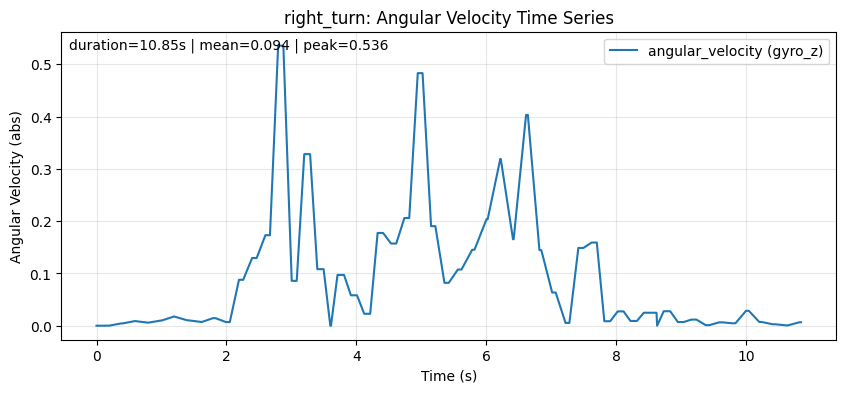

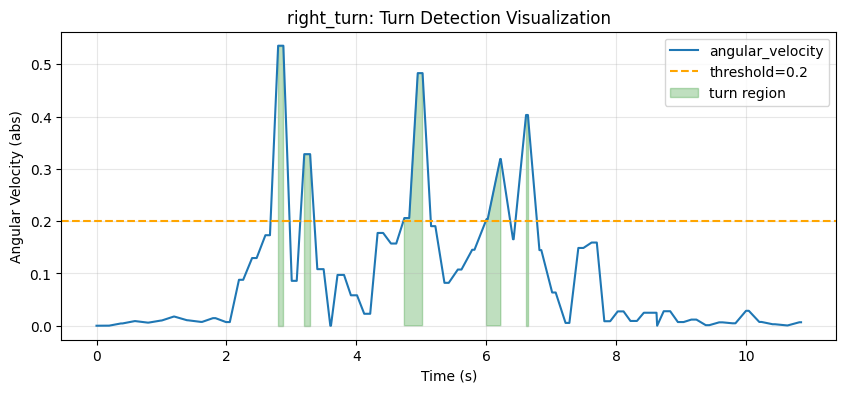

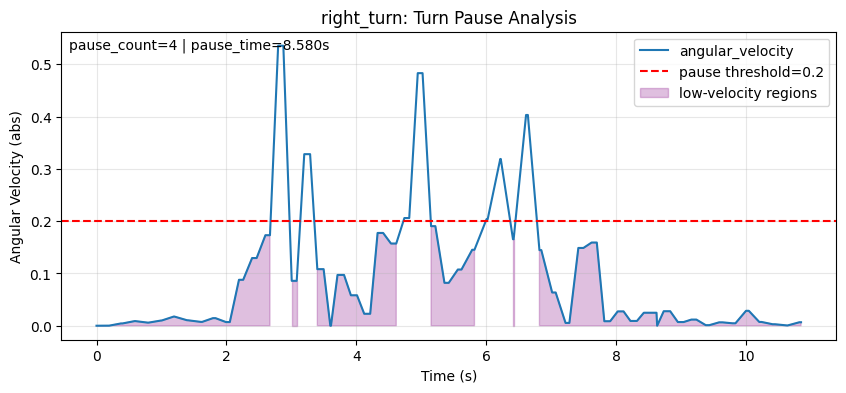

{'activity': 'right_turn', 'duration': 10.84500002861023, 'mean_angular_velocity': 0.09392356071512034, 'peak_angular_velocity': 0.5356903076171875, 'ang_vel_std': 0.12295876321658096, 'pause_count': 4.0, 'pause_time': 8.579999923706055, 'turn_signal_source': 'gyro_z'}
[SKIP] sit_to_stand: not available
[SKIP] stand_to_sit: not available

=== Validation Summary ===


,activity,duration,mean_angular_velocity,peak_angular_velocity,ang_vel_std,pause_count,pause_time,turn_signal_source
0,right_turn,10.845,0.093924,0.53569,0.122959,4.0,8.58,gyro_z


In [10]:
if CHOSEN_DIR is not None:
    BASE_DIR = Path(CHOSEN_DIR)
else:
    BASE_DIR = resolve_date_dir(DATA_ROOT, PATIENT_ID, DATE)
    if DATE is None:
        DATE = BASE_DIR.name

selected_activities = SELECTED_ACTIVITIES if SELECTED_ACTIVITIES is not None else ACTIVITY_FILTER
activity_files = discover_activity_files(BASE_DIR, selected_activities)

print("Base directory:", BASE_DIR)
print("Discovered activity files:")
for k, v in activity_files.items():
    print(f"  {k}: {v}")

all_summaries = []
turn_cache = {}

for activity in ["walk", "left_turn", "right_turn", "sit_to_stand", "stand_to_sit"]:
    if activity not in activity_files:
        print(f"[SKIP] {activity}: not available")
        continue

    path = activity_files[activity]
    print(f"\n[PROCESS] {activity}: {path}")
    try:
        df, meta = load_activity_file(path)
    except Exception as e:
        print(f"[WARN] could not load {activity}: {e}")
        continue

    if activity == "walk":
        summary = plot_walk_validation(activity, df, meta)
        all_summaries.append(summary)
        print(summary)
    elif activity in {"left_turn", "right_turn"}:
        summary, cache = plot_turn_validation(activity, df, meta)
        all_summaries.append(summary)
        turn_cache[activity] = cache
        print(summary)
    else:
        summary = plot_transition_validation(activity, df, meta)
        all_summaries.append(summary)
        print(summary)

if "left_turn" in turn_cache and "right_turn" in turn_cache:
    sym = plot_turn_symmetry_comparison(turn_cache["left_turn"], turn_cache["right_turn"])
    all_summaries.append(sym)
    print(sym)

print("\n=== Validation Summary ===")
display(pd.DataFrame(all_summaries))